In [65]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import urllib.request

from functions import apply_correlation_to_df, normalize_column

# set the themes
sns.set_theme(style="whitegrid")
%matplotlib inline

## Setup

Import libraries and configure plot styling.

# Carbon Emissions and Economic Analysis

This notebook explores the relationship between CO2 emissions and economic development by merging two datasets:

1. **CO2 Emissions** (Our World in Data, 1750-2024) — historical emissions by country
2. **GDP** (World Bank, 1960-2024) — economic output in current USD

We clean and merge both sources, compute per-capita metrics, and visualize trends for selected countries.

## CO2 Emissions Data

We load the Our World in Data CO2 dataset (79 columns) and reduce it to five key variables: `country`, `year`, `iso_code`, `population`, and `co2`. Rows without an `iso_code` are dropped — these are aggregate entities like "Africa" or "OECD" rather than individual countries. We also filter to post-1960 to align with the GDP data coverage.

In [67]:
df = pd.read_csv('data/co2_data.csv')

# choose what columns to keep (can be changed, but this is the most important)
selected_columns = ['country', 'year', 'iso_code', 'population', 'co2']

# drop the columns that are not in the selected_columns list
df = df[selected_columns].copy()

# remove entries with no iso code(Continents and other groups)
df = df[df['iso_code'].notna() & (df['iso_code'].str.strip() != '')]
df = df[df['year'] > 1960]

df



,country,year,iso_code,population,co2
211,Afghanistan,1961,AFG,9214082.0,0.491
212,Afghanistan,1962,AFG,9404410.0,0.689
213,Afghanistan,1963,AFG,9604491.0,0.707
214,Afghanistan,1964,AFG,9814317.0,0.839
215,Afghanistan,1965,AFG,10036003.0,1.007
...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,8.491
50407,Zimbabwe,2021,ZWE,15797220.0,10.223
50408,Zimbabwe,2022,ZWE,16069061.0,12.232
50409,Zimbabwe,2023,ZWE,16340829.0,13.443


## GDP Data

The World Bank GDP data arrives in **wide format** (one column per year), so we melt it into long format to match the CO2 dataset's structure. We rename `Country Code` to `iso_code` for a clean merge key and drop rows with missing GDP values.

In [68]:
# load GDP data
gdp_df = pd.read_csv('data/gdp_data.csv')

# reshape from wide to long format
# melt the year columns into rows
year_columns = [col for col in gdp_df.columns if col.isdigit()]
gdp_long = gdp_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    value_vars=year_columns,
    var_name='year',
    value_name='gdp'
)

# convert year to integer and gdp to numeric
gdp_long['year'] = gdp_long['year'].astype(int)
gdp_long['gdp'] = pd.to_numeric(gdp_long['gdp'], errors='coerce')

# rename Country Code to iso_code for merging
gdp_long = gdp_long.rename(columns={'Country Code': 'iso_code'})

# keep only the columns we need
gdp_long = gdp_long[['iso_code', 'year', 'gdp']]

# remove rows with missing GDP values
gdp_long = gdp_long.dropna(subset=['gdp'])

gdp_long

,iso_code,year,gdp
1,AFE,1960,2.420569e+10
3,AFW,1960,1.190481e+10
9,ARG,1960,1.586547e+10
13,AUS,1960,1.863568e+10
14,AUT,1960,6.624086e+09
...,...,...,...
17284,WSM,2024,1.175750e+09
17285,XKX,2024,1.119725e+10
17287,ZAF,2024,4.011450e+11
17288,ZMB,2024,2.530319e+10


## Merging the Datasets

We left-join GDP onto the CO2 dataframe using `iso_code` and `year`. A left join preserves all CO2 records and attaches GDP where available — countries or years without GDP data simply get NaN.

### Missing Data Heatmap

The heatmap below gives a quick visual diagnostic of data completeness. Each column is a variable, each row a record — bright spots indicate missing values. This is useful because it reveals **systematic gaps**: for instance, whether missingness is random or concentrated in certain time periods or countries. In our case, `co2` values are occasionally missing for earlier years in smaller nations, which is expected.

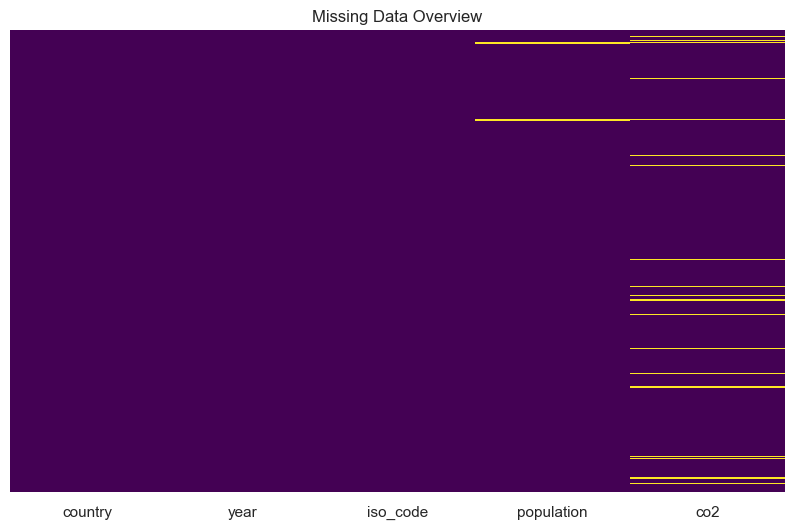

In [69]:
# merge the datasets on iso_code and year, append gdp to the right
merged_df = df.merge(
    gdp_long,
    on=['iso_code', 'year'],
    how='left',
    suffixes=('_co2', '_gdp')
)

# show the dataframe as heatmap to see where we have missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Overview")
plt.show()


## Per-Capita Metrics

Absolute CO2 and GDP figures are dominated by population size - China and India will always top the charts simply because they have the most people. Dividing by population gives us **per-capita** values that allow fairer comparisons: how much does an average person emit, and how wealthy is an average person? We use `np.divide` with a `where` guard to safely handle zero or missing population entries.

In [70]:
# extract as numpy arrays
pop_arr = merged_df['population'].values
co2_arr = merged_df['co2'].values
gdp_arr = merged_df['gdp']

# vectorized division, check for NaN or invalid values and only calculate the correct values
merged_df['co2_per_capita'] = np.divide(co2_arr, pop_arr, out = np.zeros_like(co2_arr), where = pop_arr > 0)
merged_df['gdp_per_capita'] = np.divide(gdp_arr, pop_arr, out = np.zeros_like(gdp_arr), where = pop_arr > 0)



# Correlation Analysis

It is also sensible to look at the correlation between GDP and CO2 emmisions, in order to see where economic growth is linked to higher CO2 emmisions and where it might be linked to decoupling

In [71]:
merged_df['Correlation'] = apply_correlation_to_df(merged_df)

merged_df

C:\Users\frank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\frank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,Correlation
0,Afghanistan,1961,AFG,9214082.0,0.491,NaN,5.328800e-08,NaN,0.915700
1,Afghanistan,1962,AFG,9404410.0,0.689,NaN,7.326350e-08,NaN,0.915700
2,Afghanistan,1963,AFG,9604491.0,0.707,NaN,7.361140e-08,NaN,0.915700
3,Afghanistan,1964,AFG,9814317.0,0.839,NaN,8.548735e-08,NaN,0.915700
4,Afghanistan,1965,AFG,10036003.0,1.007,NaN,1.003388e-07,NaN,0.915700
...,...,...,...,...,...,...,...,...,...
13947,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,5.468578e-07,2059.674586,-0.507579
13948,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,6.471392e-07,2613.603766,-0.507579
13949,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,7.612144e-07,2536.399713,-0.507579
13950,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,8.226633e-07,2195.223980,-0.507579


## Country-Level Analysis: GDP vs CO2 Over Time

The dual-axis line plot below overlays GDP per capita and CO2 per capita for a selected country. Using two y-axes lets us compare trends that have very different scales on a single timeline.

**Why this plot matters:** It directly tests the core question of this analysis - does economic growth go hand-in-hand with rising emissions, or can the two decouple? A country where GDP keeps climbing while CO2 flattens or drops is evidence of **decoupling**, often driven by shifts toward services, renewables, or efficiency gains. Conversely, parallel upward trends suggest the economy is still carbon-intensive.

In [72]:
# random choice of countries to be compares
country = 'Finland'
my_selection = [country]

# create a dataframe just for those countries
df_selected = merged_df[merged_df['country'].isin(my_selection)]

df_selected


,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,Correlation
4480,Finland,1961,FIN,4460998.0,14.922,5.984434e+09,0.000003,1341.501111,0.151857
4481,Finland,1962,FIN,4491739.0,16.794,6.407796e+09,0.000004,1426.573548,0.151857
4482,Finland,1963,FIN,4523897.0,19.336,6.958917e+09,0.000004,1538.257071,0.151857
4483,Finland,1964,FIN,4549092.0,22.831,7.848988e+09,0.000005,1725.396583,0.151857
4484,Finland,1965,FIN,4564150.0,25.300,8.680394e+09,0.000006,1901.864277,0.151857
...,...,...,...,...,...,...,...,...,...
4539,Finland,2020,FIN,5529616.0,37.720,2.700003e+11,0.000007,48828.040068,0.151857
4540,Finland,2021,FIN,5541069.0,37.820,2.942232e+11,0.000007,53098.636833,0.151857
4541,Finland,2022,FIN,5569300.0,36.337,2.802531e+11,0.000007,50321.063564,0.151857
4542,Finland,2023,FIN,5601185.0,31.799,2.950220e+11,0.000006,52671.351234,0.151857


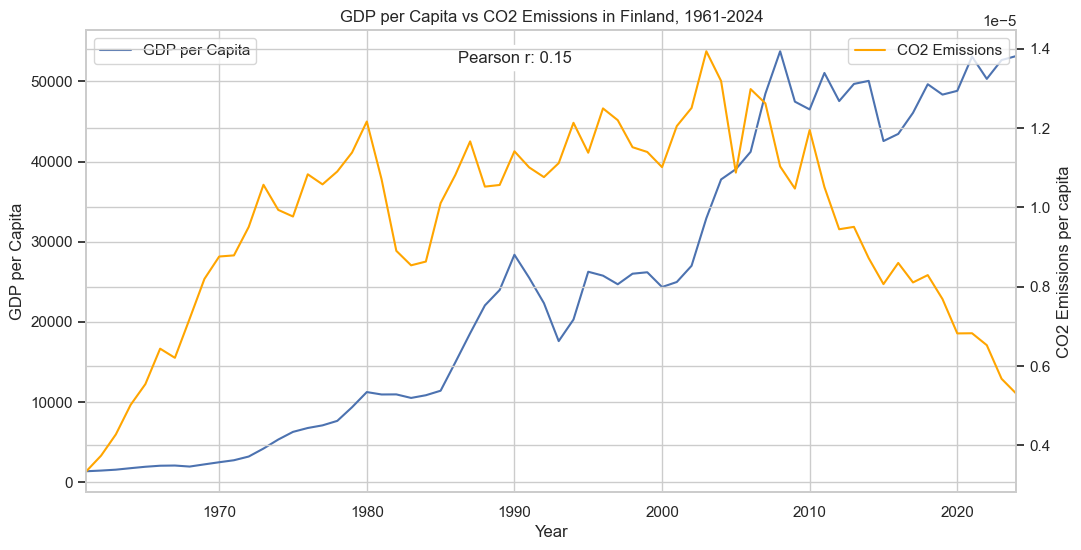

In [73]:
# create a figure and axes

# first ax is for gdp per capita
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df_selected['year'], df_selected['gdp_per_capita'], label='GDP per Capita')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP per Capita')
ax1.legend(loc='upper left')

# second ax is for co2 per capita, just a twin of the first ax
ax2 = ax1.twinx()
ax2.plot(df_selected['year'], df_selected['co2_per_capita'], label='CO2 Emissions', color='orange')
ax2.set_ylabel('CO2 Emissions per capita')
ax2.legend(loc='upper right')

# annotate
ax1.annotate(f'Pearson r: {df_selected['Correlation'].iloc[-1]:.2f}', xy=(0.4, 0.93), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", fc="w"))

# set the x axis to the min and max of the valid years, as some countries have missing data
valid_years = df_selected.dropna(subset=['gdp_per_capita', 'co2_per_capita'])['year']

if not valid_years.empty:
    min_year = valid_years.min()
    max_year = valid_years.max()
    ax1.set_xlim(min_year, max_year)

# show the plot
plt.title(f'GDP per Capita vs CO2 Emissions in {country}, {min_year}-{max_year}')
plt.show()

## Income Group Classification

To move beyond individual countries, we classify each observation by **income group** using the World Bank's GNI thresholds (Low, Lower-Middle, Upper-Middle, High). This lets us ask a structural question: do emission trajectories differ systematically between rich and poor countries?

We scrape current GNI per capita figures from Wikipedia and merge them onto our dataset.

In [74]:
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GNI_(nominal)_per_capita'

tables = pd.read_html(url, storage_options={'User-Agent': 'Mozilla/5.0'})

# table 1 contains the GNI per capita data
gni_df = tables[1]

gni_df



,Unnamed: 0,Country,GNI per capita (US$)[1][3],Year
0,NaN,High Income Economies,NaN,2024
1,–,Bermuda (UK),145150.0,2024
2,1,Liechtenstein,116600.0,2009
3,2,Norway,98170.0,2024
4,3,Switzerland,95220.0,2024
...,...,...,...,...
207,187,Madagascar,510.0,2024
208,188,Yemen,470.0,2024
209,189,Afghanistan,370.0,2023
210,190,South Sudan,350.0,2024


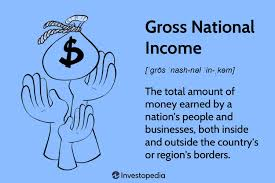

In [75]:
# normalize 
gni_df['country_clean'] = normalize_column(gni_df, 'Country')
merged_df['country_clean'] = normalize_column(merged_df, 'country')

# left merge
df_merged = pd.merge(merged_df, gni_df[['country_clean', 'GNI per capita (US$)[1][3]']], 
                     on='country_clean', how='left')

# definition of bins and labels
# https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups
bins = [0, 1145, 4515, 14005, np.inf]
labels = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']

# Erstellung der neuen Spalte basierend auf dem BIP (als Proxy für GNI)
df_merged['income_group_calc'] = pd.cut(df_merged['gdp_per_capita'], bins=bins, labels=labels)

df_merged


,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,Correlation,country_clean,GNI per capita (US$)[1][3],income_group_calc
0,Afghanistan,1961,AFG,9214082.0,0.491,NaN,5.328800e-08,NaN,0.915700,afghanistan,370.0,NaN
1,Afghanistan,1962,AFG,9404410.0,0.689,NaN,7.326350e-08,NaN,0.915700,afghanistan,370.0,NaN
2,Afghanistan,1963,AFG,9604491.0,0.707,NaN,7.361140e-08,NaN,0.915700,afghanistan,370.0,NaN
3,Afghanistan,1964,AFG,9814317.0,0.839,NaN,8.548735e-08,NaN,0.915700,afghanistan,370.0,NaN
4,Afghanistan,1965,AFG,10036003.0,1.007,NaN,1.003388e-07,NaN,0.915700,afghanistan,370.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
13947,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,5.468578e-07,2059.674586,-0.507579,zimbabwe,2260.0,Lower-Middle
13948,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,6.471392e-07,2613.603766,-0.507579,zimbabwe,2260.0,Lower-Middle
13949,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,7.612144e-07,2536.399713,-0.507579,zimbabwe,2260.0,Lower-Middle
13950,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,8.226633e-07,2195.223980,-0.507579,zimbabwe,2260.0,Lower-Middle


### Distribution of Income Groups (2024)

The countplot below shows how many countries fall into each income bracket in 2024. This is a sanity check - if one group is heavily overrepresented or nearly empty, our later comparisons across groups would be unreliable. It also reflects the current state of global inequality: we expect more countries in the lower brackets than at the top.

<Axes: xlabel='income_group_calc', ylabel='count'>

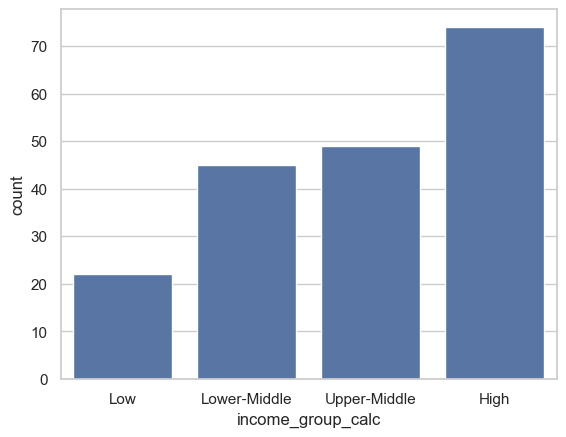

In [76]:
df_2024 = df_merged[df_merged['year'] == 2024]
sns.countplot(data=df_2024, x = 'income_group_calc')


C:\Users\frank\AppData\Local\Temp\ipykernel_25208\2217994139.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(ax=ax2, x='Correlation', y='country', data=top_decouplers, palette='magma', legend=False)


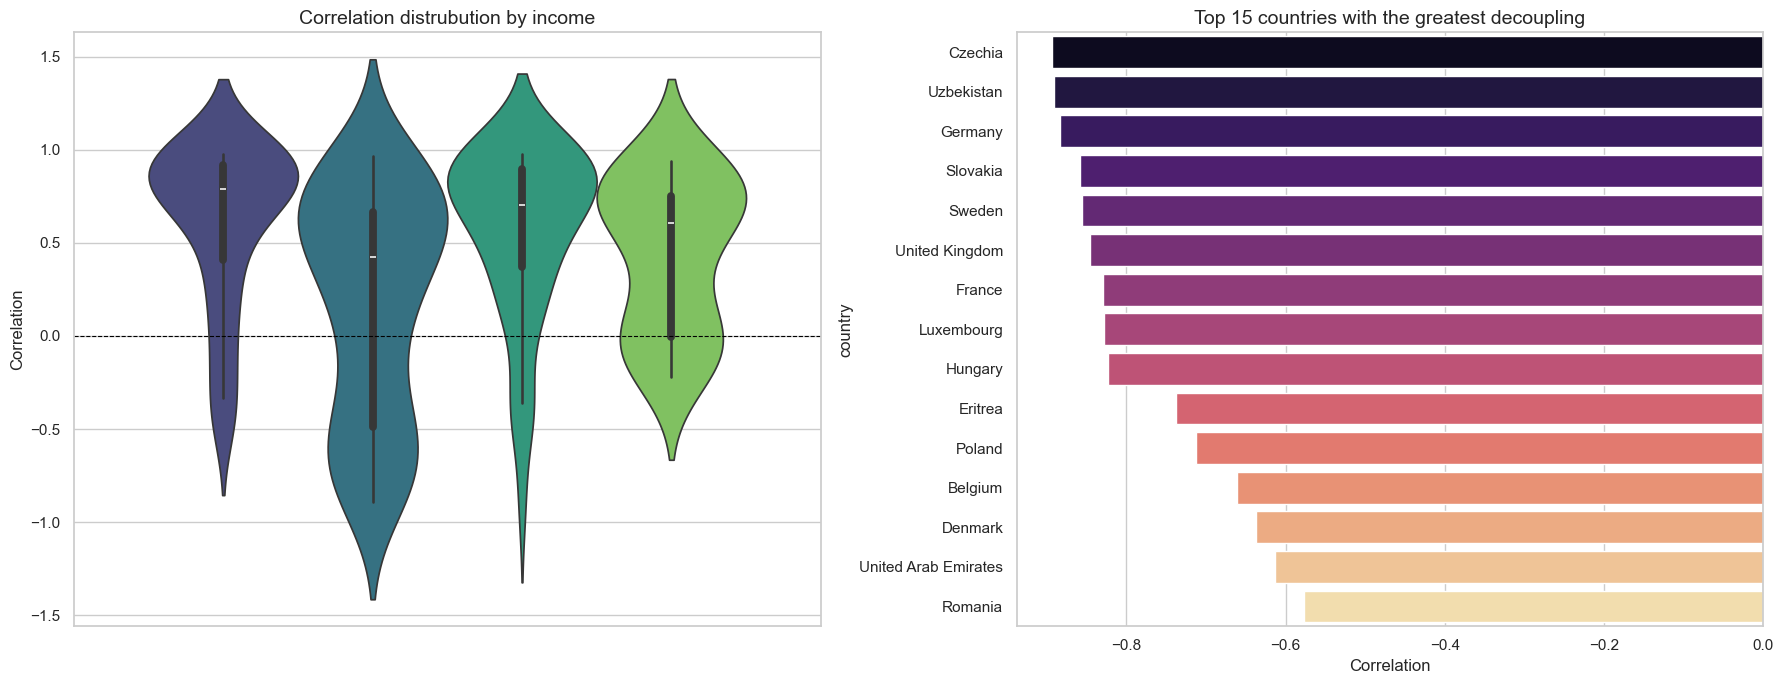

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# create a violinplot by income
sns.violinplot(ax=ax1, hue='income_group_calc', y='Correlation', data=df_2024, palette='viridis', legend=False)
ax1.set_title('Correlation distribution by income', fontsize=14)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')

# show the top decouplers
top_decouplers = df_2024.nsmallest(15, 'Correlation')

# TODO: Find out why hue screws up the visualisation
# Keep error for now
barplot = sns.barplot(ax=ax2, x='Correlation', y='country', data=top_decouplers, palette='magma', legend=False)

ax2.set_title('Top 15 countries with the greatest decoupling', fontsize=14)

plt.tight_layout()
plt.show()

Even though one might question why Uzbekistan and Czechia are on the top, it is easily explicable. Many countries from the former Block have seen a surge in the GDP while turning away from inefficient Soviet industry, replacing steel and chemical plants by more sustainable industries. 

Other than the western European states we can also observe the UAE in this graph, most likely due to diversification away from an Oil-only economy to tourism and finance. 

### Historical Emission Paths by Income Group

The FacetGrid below plots per-capita CO2 over time, split by income group. Each panel aggregates all countries in that bracket, showing the **average** emission trajectory via `sns.lineplot` (which computes mean + confidence interval across countries).

**Why a FacetGrid?** Overlaying all four groups on a single axis would clutter the plot — especially since high-income countries emit orders of magnitude more per capita than low-income ones. Separate panels with independent y-axes (`sharey=False`) let each group's trend speak for itself.

**What to look for:**
- **High income**: Emissions likely peaked and began declining — evidence of decoupling through deindustrialisation, efficiency, and renewables
- **Upper-Middle**: Rapid growth phase, potentially still climbing as industrialisation continues
- **Lower-Middle / Low**: Flat, low emissions — these countries have barely contributed to cumulative global CO2 despite large populations

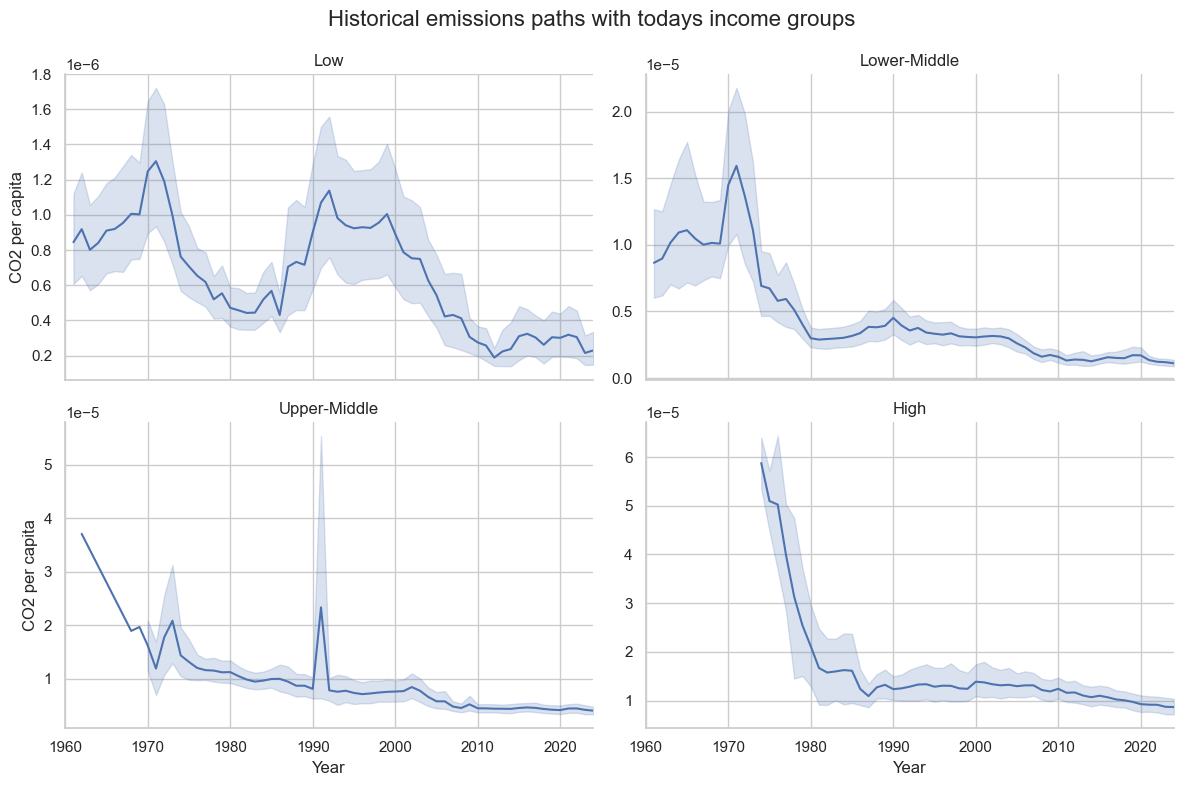

In [103]:
# compare historical emissions paths
g = sns.FacetGrid(df_merged, col="income_group_calc", col_wrap=2, height=4, aspect=1.5, sharey=False)
g.map(sns.lineplot, "year", "co2_per_capita")

g.set(xlim=(1960, 2024))
g.set_axis_labels("Year", "CO2 per capita")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Historical emissions paths with todays income groups", fontsize=16)
plt.show()

# Showing the historical emissions paths with todays income groups

Those graphs show the development of the CO2 per capita emissions of the countries in the different income groups. Interesting to see a spike in 1990 for Upper-middle-income countries, this could have multiple reasons, like the chinese industrialization, the collapse of the soviet union or the outsourcing of production to China or other countries, considered to be "Upper-middle-income" countries.